<a href="https://colab.research.google.com/github/Marcin19721205/Timeseries_Data_Processing_Basic/blob/main/InferentialDS1_extracted.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CaO content Inferential DS1
Working on Extracted Data

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

sns.set()
np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
sklearn.__version__

'1.6.1'

Read from Google Drive

In [24]:
from google.colab import files
import pandas as pd


uploaded = files.upload()


#df = pd.read_csv('df_clean_avg.csv', sep='\t')   # <-- plik oddzielany tabulatorem
df_raw = pd.read_csv('df_clean_avg.csv', sep=';')   # <-- plik oddzielany przecinkiem
print("Data loaded correctly!\n")
print(df_raw.head())

Saving df_clean_avg.csv to df_clean_avg (1).csv
Data loaded correctly!

            ChangeTime  LabUpdate Inferential_avg Inferential_med  \
0  2025-10-16 03:02:30         68       52,716789     51,08698835   
1  2025-10-16 06:33:30         60     62,41755307     63,74654023   
2  2025-10-16 08:32:30         31     44,39371878     46,67294865   
3  2025-10-16 10:35:40         32     23,31702046     23,99194305   
4  2025-10-16 12:45:30         31      20,6122777     21,00740895   

     Ratio_avg    Ratio_med       pH_avg       pH_med   CMFlow_avg  \
0  0,380589473  0,380293399  9,113029238  9,113762856  52,38471108   
1   0,35585871  0,356621683  9,092202058  9,092871666   62,5942022   
2  0,342781166  0,342676342  9,090918157  9,092871666  45,91751767   
3  0,357974786  0,357905269  9,116514277  9,113762856  24,13672841   
4    0,3405839  0,338620573  9,017560911  9,018521309  21,07282445   

    CMFlow_med     error_avg     error_med  
0  51,07588959    -15,283211  -16,91301165  
1 

Podstawowe Informacje

In [25]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ChangeTime       66 non-null     object
 1   LabUpdate        66 non-null     int64 
 2   Inferential_avg  66 non-null     object
 3   Inferential_med  66 non-null     object
 4   Ratio_avg        66 non-null     object
 5   Ratio_med        66 non-null     object
 6   pH_avg           66 non-null     object
 7   pH_med           66 non-null     object
 8   CMFlow_avg       66 non-null     object
 9   CMFlow_med       66 non-null     object
 10  error_avg        66 non-null     object
 11  error_med        66 non-null     object
dtypes: int64(1), object(11)
memory usage: 6.3+ KB


zamień przecinki na kropki, podstawowy błąd z Excela przy ustawieniach regionalnych

In [26]:
cols_to_convert = df_raw.columns.drop('ChangeTime')
df_float = df_raw.copy()
df_float[cols_to_convert] = (
    df_float[cols_to_convert]
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)


In [27]:
df_float.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ChangeTime       66 non-null     object 
 1   LabUpdate        66 non-null     int64  
 2   Inferential_avg  66 non-null     float64
 3   Inferential_med  66 non-null     float64
 4   Ratio_avg        66 non-null     float64
 5   Ratio_med        66 non-null     float64
 6   pH_avg           66 non-null     float64
 7   pH_med           66 non-null     float64
 8   CMFlow_avg       66 non-null     float64
 9   CMFlow_med       66 non-null     float64
 10  error_avg        66 non-null     float64
 11  error_med        66 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 6.3+ KB


Zamień integery na float, tak aby wszystkie były FLOAT
#Uwaga w Decision Tree Target musi być INT

In [6]:
#df_float = df_float.astype({col: 'float64' for col in df_float.select_dtypes('int').columns})

In [36]:
df_float.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ChangeTime       66 non-null     object 
 1   LabUpdate        66 non-null     int64  
 2   Inferential_avg  66 non-null     float64
 3   Inferential_med  66 non-null     float64
 4   Ratio_avg        66 non-null     float64
 5   Ratio_med        66 non-null     float64
 6   pH_avg           66 non-null     float64
 7   pH_med           66 non-null     float64
 8   CMFlow_avg       66 non-null     float64
 9   CMFlow_med       66 non-null     float64
 10  error_avg        66 non-null     float64
 11  error_med        66 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 6.3+ KB


Podstawowe Stattstyki

In [28]:
df_float.describe().T

,count,mean,std,min,25%,50%,75%,max
LabUpdate,66.0,36.954545,10.089495,20.000000,30.000000,34.500000,45.750000,68.000000
Inferential_avg,66.0,36.795141,7.420471,20.612278,34.841395,36.172216,38.886998,62.417553
Inferential_med,66.0,36.810721,7.526948,21.007409,34.708384,36.109264,38.645196,63.746540
Ratio_avg,66.0,0.369415,0.021620,0.306806,0.356445,0.365205,0.382222,0.438227
Ratio_med,66.0,0.369379,0.021702,0.306751,0.356672,0.365215,0.382230,0.438268
pH_avg,66.0,8.971518,0.122448,8.596300,8.866258,9.017246,9.074575,9.116514
pH_med,66.0,8.971384,0.122411,8.601298,8.866748,9.016063,9.075512,9.113763
CMFlow_avg,66.0,36.831135,7.488978,21.072824,34.732446,36.181700,39.504301,62.594202
CMFlow_med,66.0,36.863383,7.566658,21.404186,34.478077,36.117065,39.499082,64.000793
error_avg,66.0,-0.159405,8.983497,-16.744561,-8.353537,0.441691,5.624627,15.875388


In [29]:
df_float.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ChangeTime       66 non-null     object 
 1   LabUpdate        66 non-null     int64  
 2   Inferential_avg  66 non-null     float64
 3   Inferential_med  66 non-null     float64
 4   Ratio_avg        66 non-null     float64
 5   Ratio_med        66 non-null     float64
 6   pH_avg           66 non-null     float64
 7   pH_med           66 non-null     float64
 8   CMFlow_avg       66 non-null     float64
 9   CMFlow_med       66 non-null     float64
 10  error_avg        66 non-null     float64
 11  error_med        66 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 6.3+ KB


Przyporządkuj do klas

In [37]:
# Wyodrębnienie macierzy cech (X) i wektora klas (y)
X = df_float[['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']]
y = df_float['LabUpdate']

# Podgląd wymiarów i fragmentu danych
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPrzykładowe dane X:\n", X.head())
print("\nPrzykładowy target y:\n", y.head())


X shape: (66, 4)
y shape: (66,)

Przykładowe dane X:
    Inferential_avg  Ratio_avg    pH_avg  CMFlow_avg
0        52.716789   0.380589  9.113029   52.384711
1        62.417553   0.355859  9.092202   62.594202
2        44.393719   0.342781  9.090918   45.917518
3        23.317020   0.357975  9.116514   24.136728
4        20.612278   0.340584  9.017561   21.072824

Przykładowy target y:
 0    68
1    60
2    31
3    32
4    31
Name: LabUpdate, dtype: int64


Przypisz dane do zbiorów Treningowy i Testowy

In [38]:
import numpy as np
import pandas as pd

# 1️⃣ Przygotowanie danych wejściowych (cechy i target)
data = df_float[['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']].to_numpy()
target = df_float['LabUpdate'].to_numpy()

# 2️⃣ Utworzenie „feature_names” – nazw kolumn cech
feature_names = ['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']

# 3️⃣ Złożenie wszystkiego w DataFrame jak w Iris
df = pd.DataFrame(
    data=np.c_[data, target],
    columns=feature_names + ['Target']
)

# 4️⃣ Podgląd danych
df.head()


,Inferential_avg,Ratio_avg,pH_avg,CMFlow_avg,Target
0,52.716789,0.380589,9.113029,52.384711,68.0
1,62.417553,0.355859,9.092202,62.594202,60.0
2,44.393719,0.342781,9.090918,45.917518,31.0
3,23.317020,0.357975,9.116514,24.136728,32.0
4,20.612278,0.340584,9.017561,21.072824,31.0


In [39]:
df.columns

Index(['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg', 'Target'], dtype='object')

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Inferential_avg,66.0,36.795141,7.420471,20.612278,34.841395,36.172216,38.886998,62.417553
Ratio_avg,66.0,0.369415,0.021620,0.306806,0.356445,0.365205,0.382222,0.438227
pH_avg,66.0,8.971518,0.122448,8.596300,8.866258,9.017246,9.074575,9.116514
CMFlow_avg,66.0,36.831135,7.488978,21.072824,34.732446,36.181700,39.504301,62.594202
Target,66.0,36.954545,10.089495,20.000000,30.000000,34.500000,45.750000,68.000000


In [34]:
df['Target'].value_counts()

,count
Target,
30.0,6
28.0,5
36.0,5
34.0,4
31.0,4
46.0,4
32.0,3
48.0,3
25.0,3


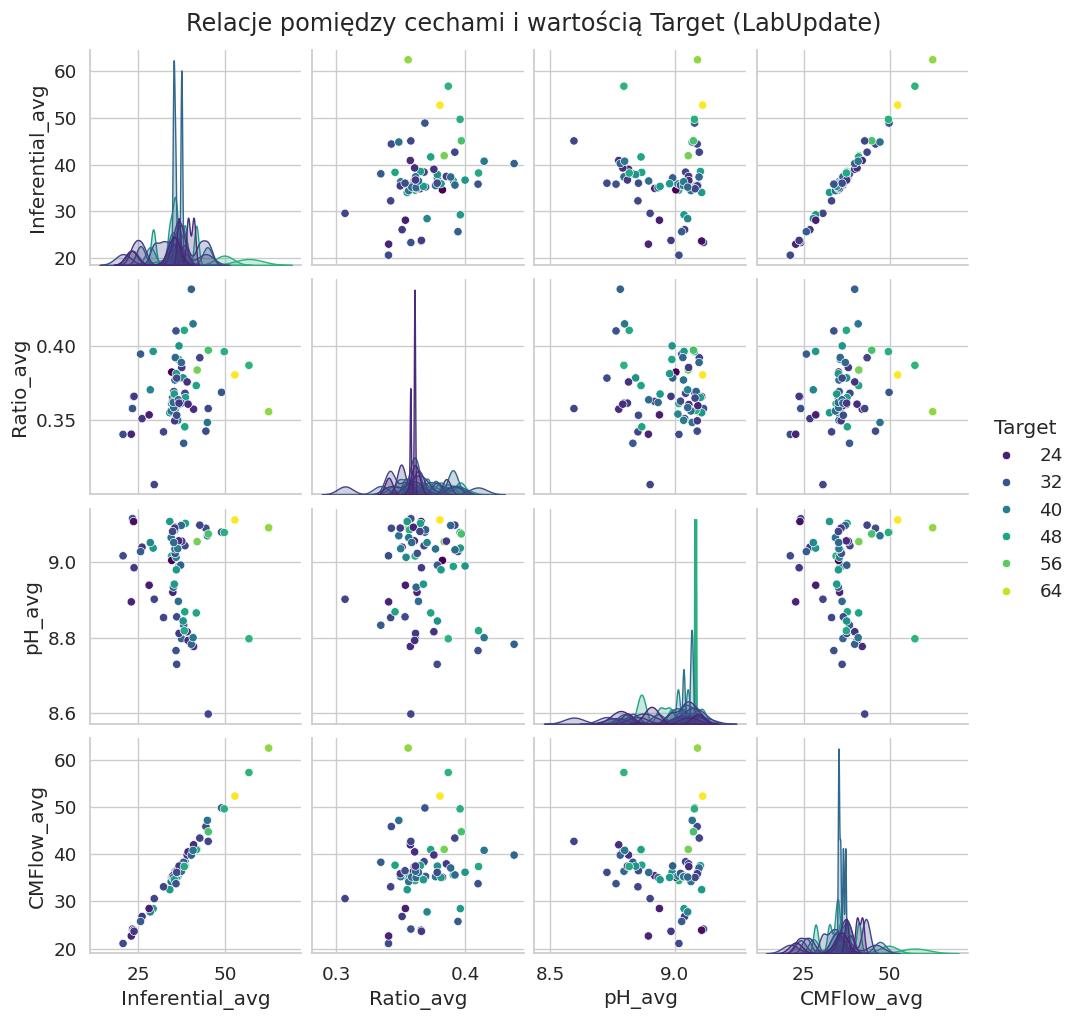

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ustawienia estetyki wykresu
sns.set(style="whitegrid", font_scale=1.2)

# Lista kolumn cech
#feature_names = ['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']
feature_names = ['Ratio_avg', 'pH_avg', 'CMFlow_avg']

# Wykres par - Różne kolory

#_ = sns.pairplot(df, vars=feature_names, hue='Target', diag_kind='kde', palette='viridis')

#_ = sns.pairplot(df, vars=feature_names, hue='Target', diag_kind='kde', palette='coolwarm')

_ = sns.pairplot(
    df,
    vars=['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg'],
    hue='Target',
    diag_kind='kde',
    palette='viridis',
    diag_kws={'bw_adjust': 0.3}   # zmniejsza szerokość pasma (ostrzejszy kształt)
)


plt.suptitle("Relacje pomiędzy cechami i wartością Target (LabUpdate)", y=1.02)
plt.show()


korelacja

In [42]:
df.corr()

,Inferential_avg,Ratio_avg,pH_avg,CMFlow_avg,Target
Inferential_avg,1.000000,0.240150,-0.080510,0.994219,0.508610
Ratio_avg,0.240150,1.000000,-0.087982,0.203454,0.273495
pH_avg,-0.080510,-0.087982,1.000000,-0.060779,0.185762
CMFlow_avg,0.994219,0.203454,-0.060779,1.000000,0.457254
Target,0.508610,0.273495,0.185762,0.457254,1.000000


# K-najbliższych sąsaiadów

In [43]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=30) #domyślnie jest 5 najbliżych sąsiadów
classifier.fit(data, target)

KNeighborsClassifier(n_neighbors=30)

In [44]:
print("=== DATA (cechy wejściowe) ===")
print(pd.DataFrame(data).head())   # pierwsze 5 wierszy

print("\nKształt danych:", np.array(data).shape)

print("\n=== TARGET (wartości docelowe) ===")
print(pd.Series(target).head())

print("\nKształt targetu:", np.array(target).shape)


=== DATA (cechy wejściowe) ===
           0         1         2          3
0  52.716789  0.380589  9.113029  52.384711
1  62.417553  0.355859  9.092202  62.594202
2  44.393719  0.342781  9.090918  45.917518
3  23.317020  0.357975  9.116514  24.136728
4  20.612278  0.340584  9.017561  21.072824

Kształt danych: (66, 4)

=== TARGET (wartości docelowe) ===
0    68
1    60
2    31
3    32
4    31
dtype: int64

Kształt targetu: (66,)


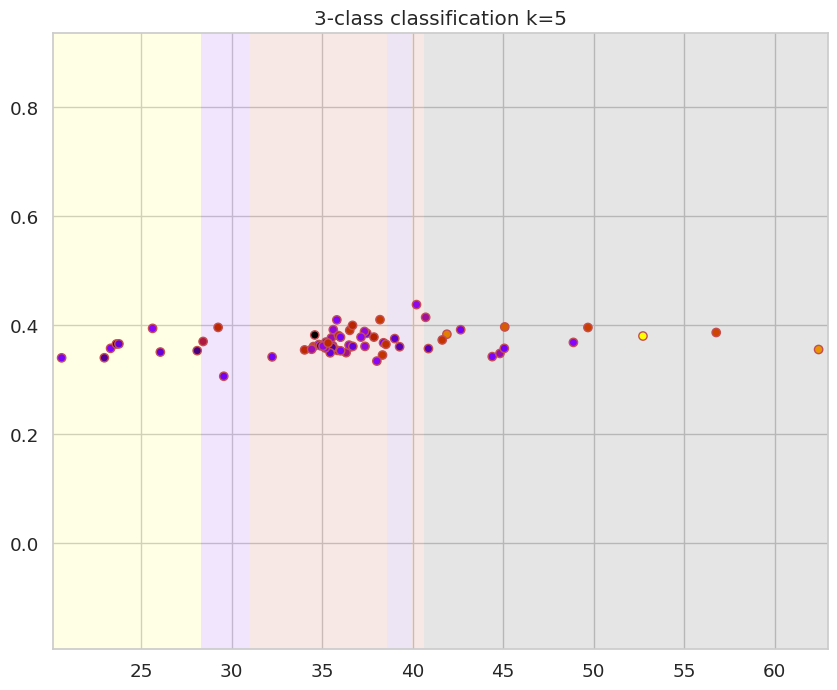

In [45]:
x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5
z_min, z_max = data[:, 2].min() - 0.5, data[:, 2].max() + 0.5
w_min, w_max = data[:, 3].min() - 0.5, data[:, 3].max() + 0.5


xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
mesh = np.c_[xx.ravel(), yy.ravel()]
# Since the classifier was trained with 4 features, we need to provide 4 features for prediction.
# We can use the mean of the other two features for the meshgrid for visualization purposes.
mean_z = np.mean(data[:, 2])
mean_w = np.mean(data[:, 3])
mesh = np.c_[xx.ravel(), yy.ravel(), np.full_like(xx.ravel(), mean_z), np.full_like(xx.ravel(), mean_w)]

Z = classifier.predict(mesh)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.pcolormesh(xx, yy, Z, cmap='gnuplot', alpha=0.1)
plt.scatter(data[:, 0], data[:, 1], c=target, cmap='gnuplot', edgecolors='r')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('3-class classification k=5')
plt.show()

Skalowane Dane

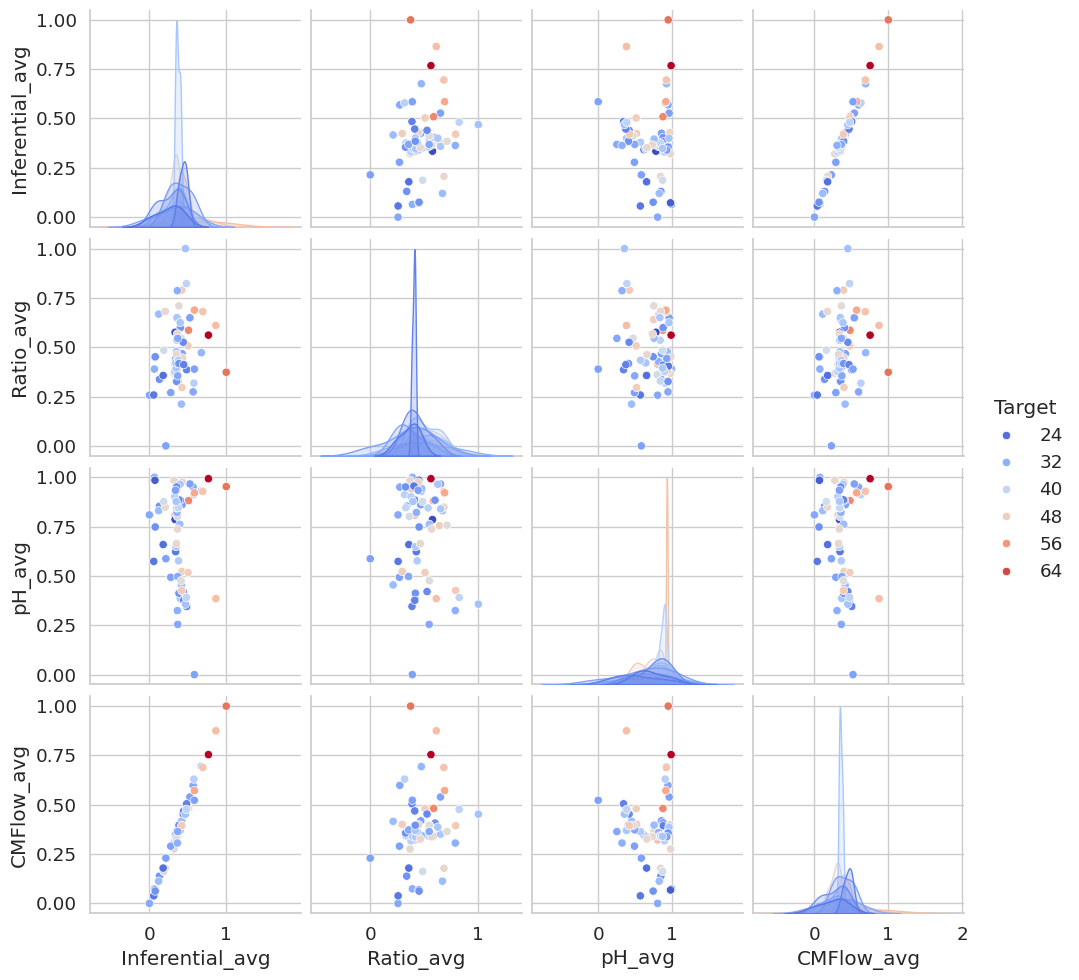

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']] = scaler.fit_transform(
    df_scaled[['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']]
)

_ = sns.pairplot(
    df_scaled,
    vars=['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg'],
    hue='Target',
    diag_kind='kde',
    palette='coolwarm'
)


stworz data set

In [46]:
# 1️⃣ Przygotowanie danych wejściowych (cechy i target)
data = df_float[['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']].to_numpy()
target = df_float['LabUpdate'].to_numpy()

# 2️⃣ Utworzenie „feature_names” – nazw kolumn cech
feature_names = ['Inferential_avg', 'Ratio_avg', 'pH_avg', 'CMFlow_avg']

# 3️⃣ Złożenie wszystkiego w DataFrame jak w Iris
df = pd.DataFrame(
    data=np.c_[data, target],
    columns=feature_names + ['Target']
)

# 4️⃣ Podgląd danych
df.head()

,Inferential_avg,Ratio_avg,pH_avg,CMFlow_avg,Target
0,52.716789,0.380589,9.113029,52.384711,68.0
1,62.417553,0.355859,9.092202,62.594202,60.0
2,44.393719,0.342781,9.090918,45.917518,31.0
3,23.317020,0.357975,9.116514,24.136728,32.0
4,20.612278,0.340584,9.017561,21.072824,31.0


In [51]:
df_float.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ChangeTime       66 non-null     object 
 1   LabUpdate        66 non-null     int64  
 2   Inferential_avg  66 non-null     float64
 3   Inferential_med  66 non-null     float64
 4   Ratio_avg        66 non-null     float64
 5   Ratio_med        66 non-null     float64
 6   pH_avg           66 non-null     float64
 7   pH_med           66 non-null     float64
 8   CMFlow_avg       66 non-null     float64
 9   CMFlow_med       66 non-null     float64
 10  error_avg        66 non-null     float64
 11  error_med        66 non-null     float64
dtypes: float64(10), int64(1), object(1)
memory usage: 6.3+ KB


Kod do Decision tree - przyporządkowanie

In [52]:
data = df_float.copy()
data = data[['Ratio_avg', 'pH_avg', 'LabUpdate']]
target = data.pop('LabUpdate')

data.head()

,Ratio_avg,pH_avg
0,0.380589,9.113029
1,0.355859,9.092202
2,0.342781,9.090918
3,0.357975,9.116514
4,0.340584,9.017561


In [69]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(max_depth=6,
                                    random_state=42,
                                    min_impurity_decrease=0.1)
classifier.fit(data, target)

DecisionTreeClassifier(max_depth=6, min_impurity_decrease=0.1, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


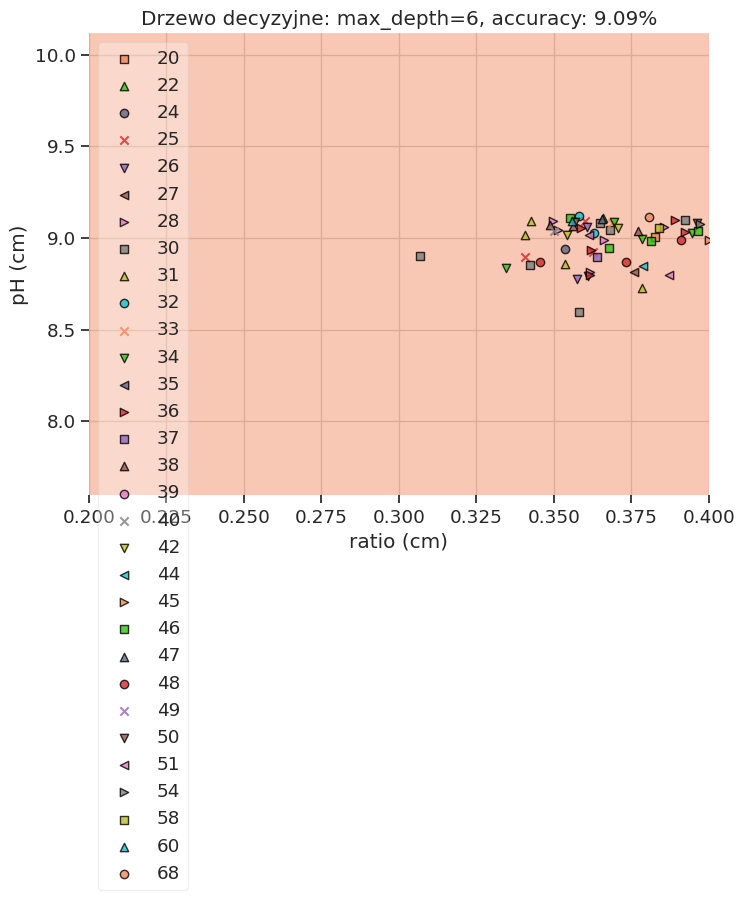

In [70]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

# Zakładam, że zmienne 'classifier', 'data' i 'target'
# są już zdefiniowane i załadowane.

colors = '#f1865b,#31c30f,#64647F,#d62728,#9467bd,#8c564b,#e377c2,#7f7f7f,#bcbd22,#17becf'

acc = classifier.score(data, target)

plt.figure(figsize=(8, 6))
plot_decision_regions(data.values, target.values, classifier, legend=2, colors=colors)
plt.xlabel('ratio (cm)')
plt.ylabel('pH (cm)')
plt.title(f'Drzewo decyzyjne: max_depth=6, accuracy: {acc * 100:.2f}%')

# Ustawienie niestandardowego zakresu osi X
plt.xlim(0.2, 0.4)

plt.show()